# 07: Evolution Without Life?

This is a controlled explanatory model, not evidence for digital life. It makes the chapter's definitions executable: variation, inheritance, and differential reproductive success can change a population without implying progress.


In [1]:
from pathlib import Path
import base64
import copy
import math
import sqlite3
from collections import Counter, defaultdict, deque
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
BOOK_FIG_DIR = ROOT / "static" / "images" / "books" / "digital-life"
FIG_DIR = ROOT / "notebooks" / "generated-figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 180


In [2]:
EXPERIMENT = {"seed": 7, "population": 400, "generations": 80, "environment_switch": 40, "mutation_rate": 0.02, "replicates": 40}
EXPERIMENT


{'seed': 7,
 'population': 400,
 'generations': 80,
 'environment_switch': 40,
 'mutation_rate': 0.02,
 'replicates': 40}

In [3]:
def run_population(control=None):
    rng = np.random.default_rng(EXPERIMENT["seed"])
    variants = rng.choice(["A","B"], size=EXPERIMENT["population"])
    quality = {"A": 0.8, "B": 0.3}  # deliberately independent of reproductive advantage
    records = []
    for t in range(EXPERIMENT["generations"] + 1):
        env = "abundant" if t < EXPERIMENT["environment_switch"] else "scarce"
        freq_a = np.mean(variants == "A")
        mean_quality = np.mean([quality[v] for v in variants])
        records.append((t, env, freq_a, mean_quality))
        if t == EXPERIMENT["generations"]:
            break
        if control == "variation_disabled":
            offspring = variants.copy()
        else:
            weights = np.where(variants == "A", 1.35 if env == "abundant" else 0.65, 0.65 if env == "abundant" else 1.35)
            if control == "reproductive_neutralized":
                weights = np.ones_like(weights, dtype=float)
            parents = rng.choice(len(variants), size=len(variants), replace=True, p=weights/weights.sum())
            offspring = variants[parents].copy()
            if control == "inheritance_shuffled":
                rng.shuffle(offspring)
            mutations = rng.random(len(offspring)) < EXPERIMENT["mutation_rate"]
            offspring[mutations] = np.where(offspring[mutations] == "A", "B", "A")
        variants = offspring
    return np.array(records, dtype=object)

runs = {name or "evolution": run_population(name) for name in [None, "variation_disabled", "inheritance_shuffled", "reproductive_neutralized"]}
for name, rec in runs.items(): print(name, rec[-1].tolist())


evolution [80, 'scarce', np.float64(0.0375), np.float64(0.3187499999999999)]
variation_disabled [80, 'scarce', np.float64(0.4675), np.float64(0.5337499999999998)]
inheritance_shuffled [80, 'scarce', np.float64(0.04), np.float64(0.31999999999999995)]
reproductive_neutralized [80, 'scarce', np.float64(0.615), np.float64(0.6074999999999998)]


## Measurement and controls

Frequency change is compared with controls that remove the mechanisms named in the chapter.


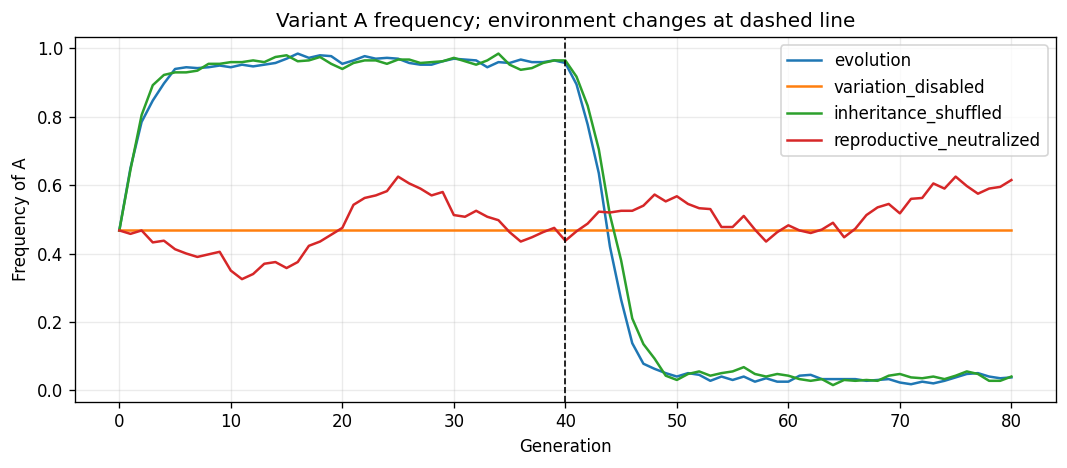

In [4]:
fig, ax = plt.subplots(figsize=(9,4))
for name, rec in runs.items(): ax.plot(rec[:,0].astype(int), rec[:,2].astype(float), label=name)
ax.axvline(EXPERIMENT["environment_switch"], color="k", lw=1, ls="--"); ax.set(title="Variant A frequency; environment changes at dashed line", xlabel="Generation", ylabel="Frequency of A"); ax.legend(); ax.grid(alpha=.25); fig.tight_layout(); fig.savefig(FIG_DIR / "ch07-variant-frequency.png", bbox_inches="tight"); plt.show()


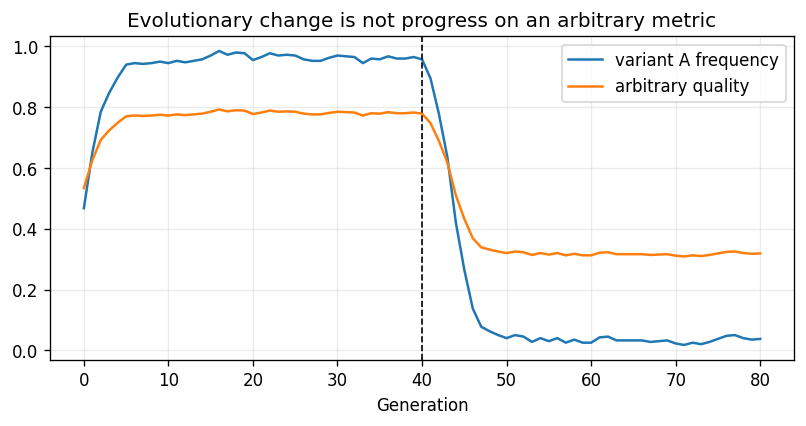

In [5]:
rec = runs["evolution"]
fig, ax = plt.subplots(figsize=(8,3.5)); ax.plot(rec[:,0].astype(int), rec[:,2].astype(float), label="variant A frequency"); ax.plot(rec[:,0].astype(int), rec[:,3].astype(float), label="arbitrary quality"); ax.axvline(EXPERIMENT["environment_switch"], color="k", lw=1, ls="--"); ax.set(title="Evolutionary change is not progress on an arbitrary metric", xlabel="Generation"); ax.legend(); ax.grid(alpha=.25); plt.show()


## Cumulative inheritance illustration

This is a toy budget model: inherited lineages keep useful discoveries; scratch lineages restart. It illustrates the proposed test, not an empirical result from an ALife system.


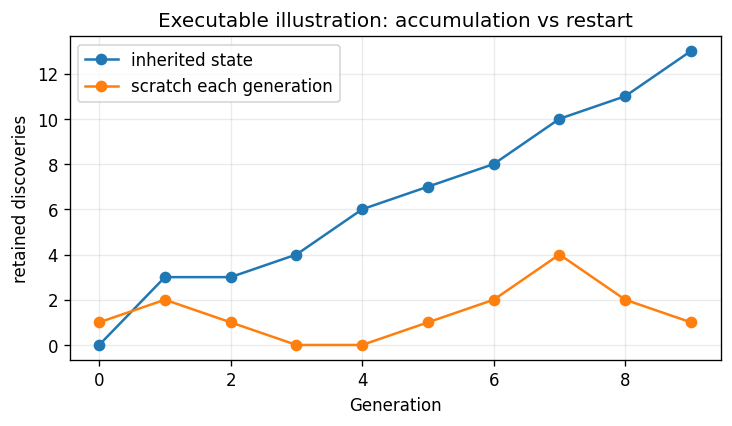

In [6]:
rng = np.random.default_rng(3); budget = 20; generations = 10
inherited = []; scratch = []; score = 0
for g in range(generations):
    score += rng.binomial(budget, 0.08)
    inherited.append(score)
    scratch.append(rng.binomial(budget, 0.08))
fig, ax = plt.subplots(figsize=(7,3.5)); ax.plot(inherited, marker="o", label="inherited state"); ax.plot(scratch, marker="o", label="scratch each generation"); ax.set(title="Executable illustration: accumulation vs restart", xlabel="Generation", ylabel="retained discoveries"); ax.legend(); ax.grid(alpha=.25); plt.show()


## Bounded conclusion

The model demonstrates definitions and controls: population composition can change through heritable variation and environment-dependent reproduction, while progress on an external quality measure need not improve. It does not demonstrate open-ended evolution or digital life.

## Provenance

**Book chapter**: `content/books/digital-life/07-evolution-without-life/index.md`

**Research scripts used**: none; chapter is conceptual and the notebook uses labelled explanatory models.

**Figures reproduced**: no checked-in book figure; notebook creates `ch07-variant-frequency.png` in `notebooks/generated-figures/`.
